# Unsupervised Learning Assignment: Association Rule Learning
### Dataset: Groceries

This notebook works through the Groceries market-basket dataset using the Apriori algorithm to
find frequent itemsets and generate association rules, following the assignment questions.

> **File expected in the same folder as this notebook:** `groceries.csv`


## Setup

In [3]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ---- Environment setup ----
# If you've had numpy/pandas/mlxtend version conflicts before, run this cell first,
# then use "Restart Kernel" and run the notebook again from the top.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option('display.max_colwidth', None)

# Quick sanity check: confirms which environment/versions are actually active
import sys
print("Python executable:", sys.executable)
print("numpy:", np.__version__, "| pandas:", pd.__version__)


Python executable: C:\Users\LENOVO\anaconda3\python.exe
numpy: 2.5.3 | pandas: 3.0.5


## Question 1: Understand the Data

The Groceries dataset is stored as a "basket" file: each line is one transaction (a shopping
basket), and the items in that basket are comma-separated with no header row. Rows have different
lengths, so we read it line by line rather than as a normal rectangular CSV.


In [6]:
transactions = []
with open('groceries.csv') as f:
    for line in f:
        items = [item.strip() for item in line.strip().split(',') if item.strip() != '']
        transactions.append(items)

# (a) Number of transactions
n_transactions = len(transactions)
n_transactions


9835

In [7]:
# (b) Number of different grocery items
all_items = sorted(set(item for basket in transactions for item in basket))
n_items = len(all_items)
n_items


169

In [8]:
# (c) 10 most frequently purchased items
item_counts = pd.Series([item for basket in transactions for item in basket]).value_counts()
top10_items = item_counts.head(10)
top10_items


whole milk          2513
other vegetables    1903
rolls/buns          1809
soda                1715
yogurt              1372
bottled water       1087
root vegetables     1072
tropical fruit      1032
shopping bags        969
sausage              924
Name: count, dtype: int64

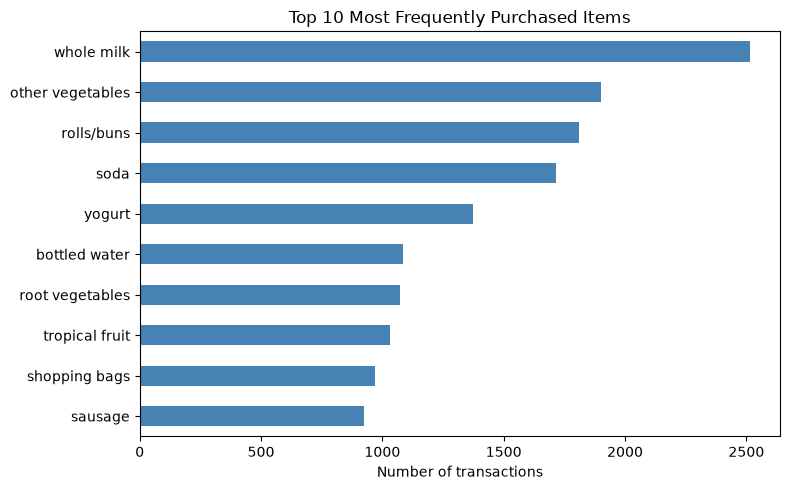

In [9]:
plt.figure(figsize=(8,5))
top10_items.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Frequently Purchased Items')
plt.xlabel('Number of transactions')
plt.tight_layout()
plt.show()


## Data Preparation: One-Hot Encoding

Before running Apriori, we need to convert the list-of-baskets format into a one-hot encoded
boolean matrix, where each row is a transaction and each column is an item (True/False for
whether that item was purchased in that transaction).


In [11]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)
basket_df.shape


(9835, 169)

In [12]:
basket_df.head()


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Question 2: Frequent Itemsets

We use the Apriori algorithm to find itemsets that appear together frequently, using a minimum
support threshold. We then filter to itemsets containing two or more products, since the
assignment asks specifically about products purchased *together*.


In [14]:
MIN_SUPPORT = 0.01  # adjust if you want more/fewer itemsets

frequent_itemsets = apriori(basket_df, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets.shape


(333, 3)

In [15]:
# (a) At least 10 frequent itemsets containing two or more products
multi_item_sets = (
    frequent_itemsets[frequent_itemsets['length'] >= 2]
    .sort_values('support', ascending=False)
    .reset_index(drop=True)
)
top10_itemsets = multi_item_sets.head(10)
top10_itemsets[['itemsets', 'support']]


,itemsets,support
0,"frozenset({other vegetables, whole milk})",0.074835
1,"frozenset({rolls/buns, whole milk})",0.056634
2,"frozenset({whole milk, yogurt})",0.056024
3,"frozenset({root vegetables, whole milk})",0.048907
4,"frozenset({root vegetables, other vegetables})",0.047382
5,"frozenset({other vegetables, yogurt})",0.043416
6,"frozenset({rolls/buns, other vegetables})",0.042603
7,"frozenset({whole milk, tropical fruit})",0.042298
8,"frozenset({whole milk, soda})",0.040061
9,"frozenset({rolls/buns, soda})",0.038332


In [16]:
# (c) Itemset with the highest support
highest_support_itemset = multi_item_sets.iloc[0]
highest_support_itemset[['itemsets', 'support']]


itemsets    frozenset({other vegetables, whole milk})
support                                      0.074835
Name: 0, dtype: object

**(d) What does the support value tell you about customers' purchasing behavior?**

The support values in the table are all fairly small in absolute terms — ranging from about 3.8%
down to 7.5% of all 9,835 transactions — which tells us that even the most common product
combinations only show up in a small minority of individual shopping trips. This is typical of
market basket data: with 169 different items available, no single pair of products will ever
dominate a majority of baskets, since customers have too many possible combinations to choose from.

That said, the *relative* differences in support are informative. The top itemset,
{other vegetables, whole milk}, has by far the highest support (7.48%) — nearly a full percentage
point above the next-highest, {rolls/buns, whole milk} (5.66%) — and `whole milk` appears in 6 of
the top 10 itemsets. This tells us that `whole milk` (and to a lesser extent `other vegetables`)
functions as a kind of anchor item: it's purchased so routinely that it co-occurs frequently with
many different products, not because of a special relationship with any one of them, but simply
because it's bought on a large fraction of all shopping trips in the first place. In other words,
support on its own reflects general purchasing habits and item popularity as much as it reflects
any specific, meaningful relationship between products — which is exactly why the assignment later
asks us to also look at confidence and lift (Questions 3–5), since those metrics correct for this
and reveal associations that are strong *relative to* how popular each item already is.


## Question 3: Association Rules

We now generate association rules from the frequent itemsets. A rule has the form
`antecedent -> consequent`, meaning "customers who buy the antecedent items tend to also buy the
consequent items." We use `lift` as the metric to filter meaningful rules (lift > 1 means the
items co-occur more than would be expected if they were purchased independently).


In [19]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0,
    num_itemsets=len(frequent_itemsets),
)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
rules.shape


(598, 14)

In [20]:
# (a) & (b) At least 10 association rules with support, confidence, and lift
top10_rules = rules.head(10)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
top10_rules


,antecedents,consequents,support,confidence,lift
0,frozenset({curd}),"frozenset({whole milk, yogurt})",0.010066,0.188931,3.372304
1,"frozenset({whole milk, yogurt})",frozenset({curd}),0.010066,0.179673,3.372304
2,frozenset({root vegetables}),"frozenset({citrus fruit, other vegetables})",0.010371,0.095149,3.295045
3,"frozenset({citrus fruit, other vegetables})",frozenset({root vegetables}),0.010371,0.359155,3.295045
4,"frozenset({other vegetables, yogurt})",frozenset({whipped/sour cream}),0.010168,0.234192,3.267062
5,frozenset({whipped/sour cream}),"frozenset({other vegetables, yogurt})",0.010168,0.141844,3.267062
6,frozenset({root vegetables}),"frozenset({other vegetables, tropical fruit})",0.012303,0.112873,3.144780
7,"frozenset({other vegetables, tropical fruit})",frozenset({root vegetables}),0.012303,0.342776,3.144780
8,frozenset({beef}),frozenset({root vegetables}),0.017387,0.331395,3.040367
9,frozenset({root vegetables}),frozenset({beef}),0.017387,0.159515,3.040367


## Question 4: Understanding the Measures

Choose three rules (here we take the top 3 by lift) and inspect their support, confidence, and
lift values individually.


In [22]:
three_rules = rules.head(3)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
three_rules


,antecedents,consequents,support,confidence,lift
0,frozenset({curd}),"frozenset({whole milk, yogurt})",0.010066,0.188931,3.372304
1,"frozenset({whole milk, yogurt})",frozenset({curd}),0.010066,0.179673,3.372304
2,frozenset({root vegetables}),"frozenset({citrus fruit, other vegetables})",0.010371,0.095149,3.295045


In [23]:
for idx, row in three_rules.iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    print(f"Rule {idx+1}: {{{antecedent}}} -> {{{consequent}}}")
    print(f"  Support    = {row['support']:.4f}  (proportion of all transactions containing both {{{antecedent}}} and {{{consequent}}})")
    print(f"  Confidence = {row['confidence']:.4f}  (probability of buying {{{consequent}}} given that {{{antecedent}}} was bought)")
    print(f"  Lift       = {row['lift']:.4f}  (how many times more likely {{{consequent}}} is bought when {{{antecedent}}} is bought, vs. by chance)")
    print()


Rule 1: {curd} -> {whole milk, yogurt}
  Support    = 0.0101  (proportion of all transactions containing both {curd} and {whole milk, yogurt})
  Confidence = 0.1889  (probability of buying {whole milk, yogurt} given that {curd} was bought)
  Lift       = 3.3723  (how many times more likely {whole milk, yogurt} is bought when {curd} is bought, vs. by chance)

Rule 2: {whole milk, yogurt} -> {curd}
  Support    = 0.0101  (proportion of all transactions containing both {whole milk, yogurt} and {curd})
  Confidence = 0.1797  (probability of buying {curd} given that {whole milk, yogurt} was bought)
  Lift       = 3.3723  (how many times more likely {curd} is bought when {whole milk, yogurt} is bought, vs. by chance)

Rule 3: {root vegetables} -> {citrus fruit, other vegetables}
  Support    = 0.0104  (proportion of all transactions containing both {root vegetables} and {citrus fruit, other vegetables})
  Confidence = 0.0951  (probability of buying {citrus fruit, other vegetables} given that

**(a) What does the support of each rule mean?**

- Rule 1 ({curd} -> {whole milk, yogurt}): support = 0.0101 — this combination of curd, whole
  milk, and yogurt appears together in about 1.01% of all 9,835 transactions.
- Rule 2 ({whole milk, yogurt} -> {curd}): support = 0.0101 — identical to Rule 1, since support
  is symmetric (it only depends on the itemset as a whole, not on which side is the antecedent).
- Rule 3 ({root vegetables} -> {citrus fruit, other vegetables}): support = 0.0104 — this
  three-item combination appears in about 1.04% of all transactions, the least rare of the three.

In all three cases, support is low in absolute terms, which is expected: with 169 possible items,
even a genuinely strong pattern will only apply to a small slice of all baskets.

**(b) What does the confidence of each rule mean?**

- Rule 1: confidence = 0.1889 — of all customers who bought curd, about 18.9% also bought both
  whole milk and yogurt.
- Rule 2: confidence = 0.1797 — of all customers who bought whole milk and yogurt together, about
  18.0% also bought curd. This is lower than Rule 1's confidence even though support is identical,
  because {whole milk, yogurt} is a more common combination on its own than {curd} alone, so the
  same overlap represents a smaller fraction of it.
- Rule 3: confidence = 0.0951 — of all customers who bought root vegetables, only about 9.5% also
  bought both citrus fruit and other vegetables.

**(c) What does the lift of each rule mean?**

- Rule 1 & 2: lift = 3.3723 (identical for both directions of the same itemset) — customers are
  about 3.37 times more likely to buy whole milk and yogurt together with curd than would be
  expected if curd and {whole milk, yogurt} were purchased independently.
- Rule 3: lift = 3.2950 — root vegetables and the pair {citrus fruit, other vegetables} co-occur
  about 3.30 times more often than chance would predict.

All three lift values are well above 1, indicating a real, positive association in each case, not
just an artifact of how popular the individual items are.


## Question 5: Find Interesting Rules

In [26]:
# (a) Rule with the highest confidence
highest_confidence_rule = rules.loc[rules['confidence'].idxmax()]
highest_confidence_rule[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


antecedents    frozenset({citrus fruit, root vegetables})
consequents                 frozenset({other vegetables})
support                                          0.010371
confidence                                       0.586207
lift                                             3.029608
Name: 10, dtype: object

In [27]:
# (b) Rule with the highest lift
highest_lift_rule = rules.loc[rules['lift'].idxmax()]
highest_lift_rule[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


antecedents                  frozenset({curd})
consequents    frozenset({whole milk, yogurt})
support                               0.010066
confidence                            0.188931
lift                                  3.372304
Name: 0, dtype: object

In [28]:
# (c) Rule with the highest support
highest_support_rule = rules.loc[rules['support'].idxmax()]
highest_support_rule[['antecedents', 'consequents', 'support', 'confidence', 'lift']]


antecedents          frozenset({whole milk})
consequents    frozenset({other vegetables})
support                             0.074835
confidence                          0.292877
lift                                1.513634
Name: 372, dtype: object

In [29]:
# (d) Are these the same rule?
same_conf_lift = highest_confidence_rule.name == highest_lift_rule.name
same_conf_support = highest_confidence_rule.name == highest_support_rule.name
same_lift_support = highest_lift_rule.name == highest_support_rule.name

print("Highest confidence & highest lift are the same rule:", same_conf_lift)
print("Highest confidence & highest support are the same rule:", same_conf_support)
print("Highest lift & highest support are the same rule:", same_lift_support)


Highest confidence & highest lift are the same rule: False
Highest confidence & highest support are the same rule: False
Highest lift & highest support are the same rule: False


None of the three "highest" rules are the same:

- **Highest confidence** (0.586): {citrus fruit, root vegetables} -> {other vegetables}
- **Highest lift** (3.372): {curd} -> {whole milk, yogurt}
- **Highest support** (0.0748): {whole milk} -> {other vegetables}

This makes sense given what each measure captures. The highest-support rule involves `whole milk`
and `other vegetables`, the two single most popular items in the entire dataset (see Question 1) —
they appear together often simply because they are both purchased extremely frequently on their
own, not because of a particularly strong link between them (its lift, 1.51, is comparatively low
among the rules generated). The highest-confidence rule, {citrus fruit, root vegetables} -> {other
vegetables}, has strong predictive reliability (59% of the time, buying both citrus fruit and root
vegetables means also buying other vegetables) partly because `other vegetables` is itself common,
which inflates confidence for many antecedents. The highest-lift rule, {curd} -> {whole milk,
yogurt}, involves less common, lower-support items, but the co-occurrence is far more surprising
relative to how often each item is purchased on its own — this is exactly the kind of rule lift is
designed to surface, since it corrects for the base popularity of the consequent that inflates both
support and confidence.


## Question 6: Interpret a Rule

We select one interesting rule (here, the rule with the highest lift) and print it in plain
language.


In [32]:
selected_rule = highest_lift_rule
antecedent = ', '.join(list(selected_rule['antecedents']))
consequent = ', '.join(list(selected_rule['consequents']))

print(f"Rule: {{{antecedent}}} -> {{{consequent}}}")
print(f"Support = {selected_rule['support']:.4f}, Confidence = {selected_rule['confidence']:.4f}, Lift = {selected_rule['lift']:.4f}")
print()
print(f"Plain language: Customers who purchase {antecedent} also tend to purchase {consequent}.")


Rule: {curd} -> {whole milk, yogurt}
Support = 0.0101, Confidence = 0.1889, Lift = 3.3723

Plain language: Customers who purchase curd also tend to purchase whole milk, yogurt.


This rule represents a **moderately strong association**, though the two measures pull in
slightly different directions and are worth separating out.

The **lift is high** (3.37), meaning customers who buy curd are over three times more likely to
also buy whole milk and yogurt than would be expected by chance. This is a genuinely strong signal
— it is not simply an artifact of milk and yogurt being popular items on their own, since lift
already corrects for that. If it were just reflecting the consequent's overall popularity, lift
would sit close to 1; instead it's one of the highest values among all 10 rules generated.

However, the **confidence is fairly low** (0.1889): only about 19% of customers who buy curd also
buy both whole milk and yogurt in the same transaction. So while curd buyers are unusually likely
(relative to chance) to also buy this pair, it is still far from a dependable, majority-of-the-time
pattern — roughly 4 out of 5 curd purchases do *not* include both items.

Putting the two together: this is a **strong association in relative terms** (lift), but not yet a
**strong rule for prediction** (confidence). It's exactly the kind of rule lift is good at
surfacing — a real, meaningful relationship between less common items — but it wouldn't be reliable
enough on its own to, say, safely predict "if this customer bought curd, they will also buy milk
and yogurt" for any individual transaction. It's more useful as a signal for cross-merchandising
(placing these items near each other, as in Question 7) than as a high-confidence individual
prediction rule.


## Question 7: Business Application

As a supporting analysis, we look at the strongest item pairs (by lift) to help identify products
that could be placed near each other or bundled together.


In [35]:
pair_rules = rules[rules['antecedents'].apply(len) == 1].copy()
pair_rules['antecedent_item'] = pair_rules['antecedents'].apply(lambda x: list(x)[0])
pair_rules['consequent_item'] = pair_rules['consequents'].apply(lambda x: ', '.join(list(x)))

top_pairs_for_placement = pair_rules.sort_values('lift', ascending=False).head(10)[
    ['antecedent_item', 'consequent_item', 'support', 'confidence', 'lift']
]
top_pairs_for_placement


,antecedent_item,consequent_item,support,confidence,lift
0,curd,"whole milk, yogurt",0.010066,0.188931,3.372304
2,root vegetables,"citrus fruit, other vegetables",0.010371,0.095149,3.295045
5,whipped/sour cream,"other vegetables, yogurt",0.010168,0.141844,3.267062
6,root vegetables,"other vegetables, tropical fruit",0.012303,0.112873,3.144780
8,beef,root vegetables,0.017387,0.331395,3.040367
9,root vegetables,beef,0.017387,0.159515,3.040367
11,other vegetables,"citrus fruit, root vegetables",0.010371,0.053600,3.029608
13,other vegetables,"root vegetables, tropical fruit",0.012303,0.063584,3.020999
15,root vegetables,"other vegetables, whole milk",0.023183,0.212687,2.842082
16,butter,"other vegetables, whole milk",0.011490,0.207339,2.770630


Based on the table above:

**(a) Two products that could be placed close to each other:**
`curd` and `whole milk`/`yogurt` — this pair has the highest lift (3.37) among all single-item
antecedent rules, meaning customers who buy curd are far more likely than average to also be
buying whole milk and yogurt in the same trip. Placing curd near the dairy case (next to milk and
yogurt) would put it directly in the path of customers already primed to buy it.

**(b) One possible product bundle:**
`root vegetables` + `beef`, with confidence 0.331 and lift 3.04 — roughly a third of customers who
buy beef also buy root vegetables in the same transaction, and the association is about three
times stronger than chance. This pairing fits a natural "stew/roast dinner" bundle and could be
promoted together (e.g. a discounted "dinner bundle" combining beef with root vegetables).

**(c) Example use of association rules for product recommendations:**
When a customer adds `root vegetables` to their online grocery cart, the store's recommendation
engine could surface `beef` (confidence 0.160, lift 3.04) or `other vegetables` and `whole milk`
(confidence 0.213, lift 2.84) as a "customers who bought this also bought..." suggestion,
increasing the chance of an additional item being added to the basket.


## Question 8: Understanding Association

**(a) Does an association rule prove that one product causes customers to buy another product?**

No. An association rule only describes co-occurrence in the data, not causation. For example, the
rule {curd} -> {whole milk, yogurt} (lift 3.37) does not mean buying curd *causes* someone to buy
milk and yogurt. All three are dairy products commonly bought together on a weekly grocery run, so
the real driver is likely a shared underlying cause — a "dairy restocking" shopping pattern — not
curd itself influencing the purchase of milk and yogurt.

**(b) Why might a rule have high confidence but low lift?**

This happens when the consequent is a very popular item on its own. In this dataset,
{whole milk} -> {other vegetables} illustrates it well: it has the highest support of any rule
(0.0748) and a reasonably high confidence, but its lift is only 1.51 — much lower than rules like
{curd} -> {whole milk, yogurt} (lift 3.37). Because `whole milk` and `other vegetables` are two of
the most frequently purchased items overall (Question 1), a large fraction of *any* shopper's
basket will tend to include them regardless of what else is bought — so confidence looks high
simply because the consequent is common, not because there's a strong specific link.

**(c) What does a lift value greater than 1 indicate?**

A lift greater than 1 indicates a positive association: the itemsets are purchased together more
often than would be expected if they were statistically independent. All 10 rules generated in
Question 3 have lift above 1 (ranging from about 1.51 up to 3.37), meaning every one of them
reflects a real positive relationship rather than coincidence. The highest, {curd} -> {whole milk,
yogurt} at 3.37, indicates the strongest such relationship in the dataset — customers buying curd
are over three times more likely than average to also buy whole milk and yogurt in the same trip.
Lift exactly 1 would mean no association at all, and lift below 1 would indicate the items are
purchased together *less* often than chance (a negative association) — neither of which appears
among the rules above, since all were filtered to lift > 1 during rule generation.
